In [1]:
import pandas as pd
import numpy as np
import os
import json

import optuna
from optuna import Trial
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import kaggle

kaggle_config_dir = os.environ.get("KAGGLE_CONFIG_DIR", os.path.expanduser("~/.config/kaggle"))
with open(os.path.join(kaggle_config_dir, "kaggle.json")) as f:
    _kaggle_creds = json.load(f)
os.environ.setdefault("KAGGLE_USERNAME", _kaggle_creds["username"])
os.environ.setdefault("KAGGLE_KEY", _kaggle_creds["key"])

/home/osman-tekdamar/Projects/forCV/ING_Datathon/.claude/worktrees/init-claude-md/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'699a97a4eb31e71942a5d74804da53b0'

In [2]:
train_data = pd.read_csv("train_data.csv")
test_data = pd.read_csv("test_data.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [3]:
from metrics import recall_at_k, lift_at_k, convert_auc_to_gini, ing_hubs_datathon_metric

In [4]:
train_data

,age,tenure,cust_age_month,uses_mobile_eft,uses_cc,uses_any_digital_channel,mobile_eft_cnt_mean,mobile_eft_cnt_std,mobile_eft_cnt_min,mobile_eft_cnt_max,...,work_sector_Finance,work_sector_Healthcare,work_sector_Manufacturing,work_sector_Other,work_sector_Public Sector,work_sector_Retail,work_sector_Retired,work_sector_Student,work_sector_Technology,work_sector_Unemployed
0,64,135,633,1.0,0.0,1.0,2.238095,1.220851,1.0,5.0,...,0,0,0,0,0,0,0,0,1,0
1,22,47,217,1.0,1.0,1.0,1.676471,1.006662,1.0,4.0,...,0,0,0,0,0,0,0,1,0,0
2,27,108,216,1.0,1.0,1.0,2.555556,1.476309,1.0,6.0,...,1,0,0,0,0,0,0,0,0,0
3,40,187,293,1.0,1.0,1.0,7.142857,3.307839,4.0,14.0,...,0,0,0,0,0,0,0,0,0,1
4,64,218,550,1.0,1.0,1.0,0.793103,1.372675,0.0,5.0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133282,54,217,431,1.0,1.0,1.0,1.393939,1.657170,0.0,6.0,...,0,0,0,0,1,0,0,0,0,0
133283,47,37,527,1.0,1.0,1.0,2.000000,1.174440,1.0,5.0,...,0,0,0,0,1,0,0,0,0,0
133284,66,227,565,1.0,1.0,1.0,9.055556,5.796277,1.0,22.0,...,0,0,0,0,0,0,1,0,0,0
133285,31,156,216,1.0,1.0,1.0,3.576923,1.836803,1.0,7.0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
X = train_data.drop("churn", axis=1)
y = train_data["churn"]

In [6]:
def objective(trial: Trial, X: pd.DataFrame, y: np.ndarray, n_splits: int = 5) -> float:
    # Hyperparametreler
    params = {
        'objective': 'binary',
        'verbose': False,
        'metric': 'binary_logloss',
        'verbosity': -1,
        'random_state': 42,
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 30, 200),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 10),
    }

    # Dengesizlik: Pozitif sınıf ağırlığını optimize et
    neg, pos = np.bincount(y)
    scale_pos_weight = neg / pos
    params['scale_pos_weight'] = trial.suggest_float('scale_pos_weight', scale_pos_weight * 0.5, scale_pos_weight * 2)

    # K-Fold
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    custom_scores = []

    for train_idx, val_idx in kf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )

        y_pred_proba = model.predict_proba(X_val)[:, 1]

        # Özel metrik
        score = ing_hubs_datathon_metric(y_val, y_pred_proba)
        custom_scores.append(score)

    return np.mean(custom_scores)

In [7]:
# Optimize et
# storage + load_if_exists: kernel yeniden başlasa bile trial geçmişi kaybolmaz,
# aynı study_name ile tekrar çalıştırıldığında kaldığı yerden devam eder.
study = optuna.create_study(
    direction='maximize',
    study_name='lgbm-churn-ing-metric',
    storage='sqlite:///optuna_studies.db',
    load_if_exists=True,
)
study.optimize(
    lambda trial: objective(trial, X, y),
    n_trials=50,
    show_progress_bar=True
)

print("Best trial score:", study.best_trial.value)
print("Best params:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2026-07-16 16:30:51,782] A new study created in RDB with name: lgbm-churn-ing-metric
Best trial: 0. Best value: 0.999346:   2%|▏         | 1/50 [00:04<03:23,  4.16s/it]

[I 2026-07-16 16:30:55,937] Trial 0 finished with value: 0.9993462294194485 and parameters: {'num_leaves': 127, 'max_depth': 12, 'learning_rate': 0.0721579551109585, 'n_estimators': 856, 'subsample': 0.7051273959075994, 'colsample_bytree': 0.6433794108460004, 'reg_alpha': 9.550864033303412, 'reg_lambda': 7.297722276964696, 'min_child_samples': 88, 'subsample_freq': 4, 'scale_pos_weight': 9.536312190631985}. Best is trial 0 with value: 0.9993462294194485.


Best trial: 1. Best value: 1.08656:   4%|▍         | 2/50 [00:07<03:09,  3.94s/it] 

[I 2026-07-16 16:30:59,725] Trial 1 finished with value: 1.0865607241732647 and parameters: {'num_leaves': 121, 'max_depth': 5, 'learning_rate': 0.016684843669342607, 'n_estimators': 678, 'subsample': 0.9908597370047786, 'colsample_bytree': 0.9426679904932644, 'reg_alpha': 7.949235659927915, 'reg_lambda': 8.295196183434028, 'min_child_samples': 60, 'subsample_freq': 3, 'scale_pos_weight': 9.336700478459367}. Best is trial 1 with value: 1.0865607241732647.


Best trial: 1. Best value: 1.08656:   6%|▌         | 3/50 [00:12<03:22,  4.32s/it]

...

[I 2026-07-16 16:34:18,410] Trial 47 finished with value: 1.14091796856323 and parameters: {'num_leaves': 115, 'max_depth': 12, 'learning_rate': 0.012042574627956576, 'n_estimators': 860, 'subsample': 0.9362998952816644, 'colsample_bytree': 0.724297020160416, 'reg_alpha': 2.8779096458945306, 'reg_lambda': 4.705591368716467, 'min_child_samples': 10, 'subsample_freq': 10, 'scale_pos_weight': 3.396920227723604}. Best is trial 13 with value: 1.146434827662473.


Best trial: 13. Best value: 1.14643:  98%|█████████▊| 49/50 [03:33<00:05,  5.61s/it]

[I 2026-07-16 16:34:24,876] Trial 48 finished with value: 1.1449860647059111 and parameters: {'num_leaves': 131, 'max_depth': 13, 'learning_rate': 0.011768375875803766, 'n_estimators': 874, 'subsample': 0.935134175531642, 'colsample_bytree': 0.7210057923304175, 'reg_alpha': 3.2830239580110234, 'reg_lambda': 4.697309224708972, 'min_child_samples': 10, 'subsample_freq': 9, 'scale_pos_weight': 3.316696060922051}. Best is trial 13 with value: 1.146434827662473.


Best trial: 13. Best value: 1.14643: 100%|██████████| 50/50 [03:38<00:00,  4.38s/it]

[I 2026-07-16 16:34:30,585] Trial 49 finished with value: 1.1427937138309232 and parameters: {'num_leaves': 131, 'max_depth': 13, 'learning_rate': 0.01758948013691454, 'n_estimators': 864, 'subsample': 0.9131080907481829, 'colsample_bytree': 0.7100324828851989, 'reg_alpha': 3.4001563782580377, 'reg_lambda': 4.66537663471983, 'min_child_samples': 10, 'subsample_freq': 9, 'scale_pos_weight': 3.0417738403075822}. Best is trial 13 with value: 1.146434827662473.
Best trial score: 1.146434827662473
Best params:
  num_leaves: 92
  max_depth: 7
  learning_rate: 0.010045200142368567
  n_estimators: 788
  subsample: 0.6585702307790033
  colsample_bytree: 0.8499049776865524
  reg_alpha: 1.9453019741588662
  reg_lambda: 4.168281034542763
  min_child_samples: 37
  subsample_freq: 6
  scale_pos_weight: 3.0611361465171187


In [8]:
# En iyi parametreler
best_params = study.best_trial.params.copy()
best_params['objective'] = 'binary'
best_params['random_state'] = 42

# Final model
final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X, y)

# Tahmin
y_pred_proba = final_model.predict_proba(X)
# Tüm metrikleri yazdır
gini = convert_auc_to_gini(roc_auc_score(y, y_pred_proba[:, 1]))
recall_10 = recall_at_k(y, y_pred_proba[:, 1], k=0.1)
lift_10 = lift_at_k(y, y_pred_proba[:, 1], k=0.1)
final_score = ing_hubs_datathon_metric(y, y_pred_proba[:, 1])

print("\n📊 TRAIN SETİ SKORLARI (in-sample — GENELLEME TAHMİNİ DEĞİLDİR, gerçek performans için aşağıdaki 5-Fold CV sonucuna bakın):")
print(f"Gini:              {gini:.4f}")
print(f"Recall@10%:        {recall_10:.4f}")
print(f"Lift@10%:          {lift_10:.4f}")
print(f"Final ING Metric:  {final_score:.4f}")


📊 TRAIN SETİ SKORLARI (in-sample — GENELLEME TAHMİNİ DEĞİLDİR, gerçek performans için aşağıdaki 5-Fold CV sonucuna bakın):
Gini:              0.5989
Recall@10%:        0.3212
Lift@10%:          3.2119
Final ING Metric:  1.6654


In [9]:
cv_scores = []
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models:list[lgb.LGBMClassifier] = []
for train_idx, val_idx in kf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    
    model = lgb.LGBMClassifier(**best_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    score = ing_hubs_datathon_metric(y_val, y_pred_proba)
    cv_scores.append(score)
    models.append(model)

print(f"\n✅ 5-Fold CV ING Metric: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")


✅ 5-Fold CV ING Metric: 1.1464 ± 0.0239


In [10]:
import joblib

joblib.dump(models, "lgbm_fold_models.joblib")
print("5-fold LightGBM ensemble modelleri 'lgbm_fold_models.joblib' dosyasına kaydedildi.")

5-fold LightGBM ensemble modelleri 'lgbm_fold_models.joblib' dosyasına kaydedildi.


/home/osman-tekdamar/Projects/forCV/ING_Datathon/.claude/worktrees/init-claude-md/.venv/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


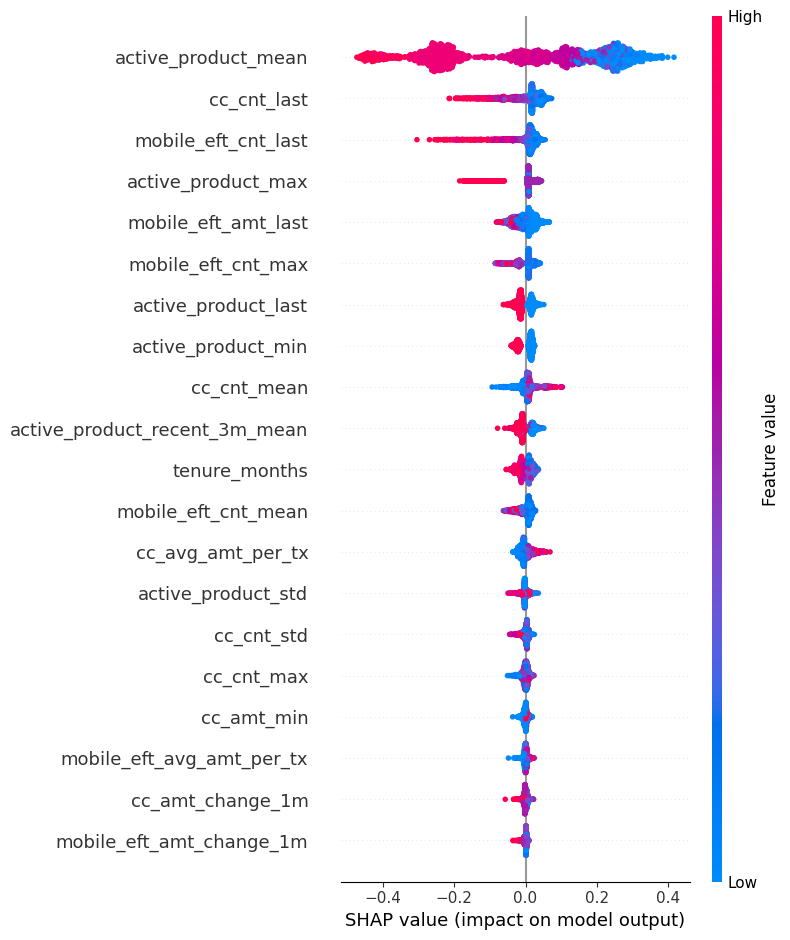

In [11]:
import shap
import matplotlib.pyplot as plt

# İlk fold modeli üzerinden SHAP analizi: hangi feature'ların churn tahminini
# en çok etkilediğini ve hangi yönde etkilediğini gösterir. İş birimine
# (retention/CRM ekipleri) modelin kararlarını açıklamak için kullanılabilir.
explainer = shap.TreeExplainer(models[0])
X_sample = X.sample(n=min(2000, len(X)), random_state=42)
shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

In [12]:
test_predictions = np.mean([m.predict_proba(test_data)[:,1] for m in models], axis=0)

In [13]:
sample_submission["churn"] = test_predictions

In [14]:
sample_submission.to_csv('/tmp/submission.csv', index=False)
kaggle.api.competition_submit(
    file_name='/tmp/submission.csv', 
    message='lgbm with Optuna kfold and feature engineering history data ensemble kfold models', 
    competition='ing-hubs-turkiye-datathon'
)

100%|██████████| 1.07M/1.07M [00:01<00:00, 795kB/s]


{"message": "Successfully submitted to ING Hubs T\u00fcrkiye Datathon", "ref": 54761681}